In [ ]:
Write a program to simulate and analyze daily stock prices over one year and generate
the stock prices, calculate some basic metrics, and visualize the data with additional
features like moving averages and visualize the same.

First 5 rows:
                 Close
Date                  
2025-01-01  101.043428
2025-01-02  100.814536
2025-01-03  102.170872
2025-01-06  105.334143
2025-01-07  104.893523

Basic Metrics:
Average Daily Return: 0.0005427938401257518
Volatility (Std Dev): 0.01950911558371005
Max Price: 113.11171272373575
Min Price: 79.04449139151173


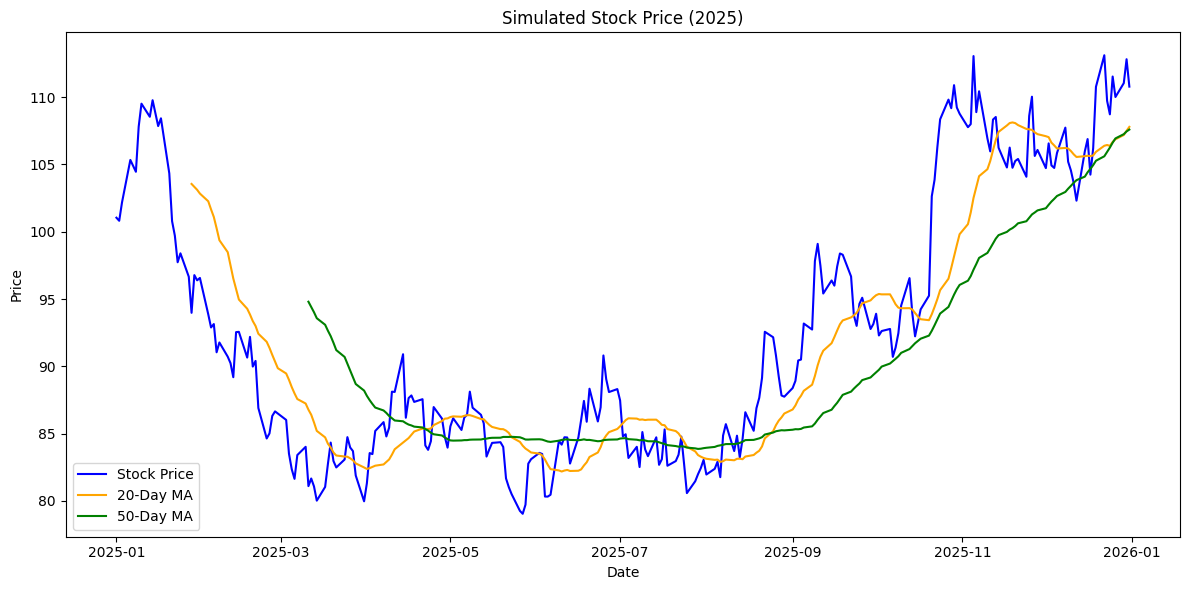

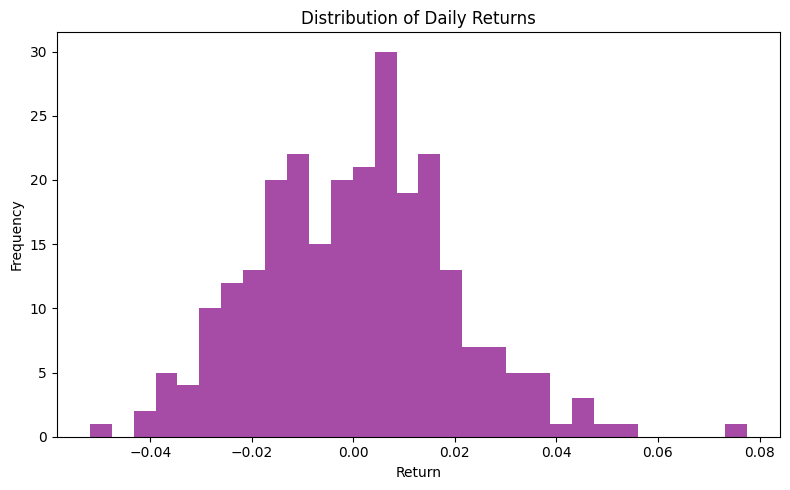

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------
# Generate time series (1 year)
# -----------------------------------
dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='B')  # Business days

# -----------------------------------
# Simulate stock prices using random walk
# -----------------------------------
np.random.seed(42)

initial_price = 100
returns = np.random.normal(loc=0.0005, scale=0.02, size=len(dates))  # daily returns

price = [initial_price]

for r in returns:
    price.append(price[-1] * (1 + r))

# Remove first extra value
price = price[1:]

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Close': price
})

df.set_index('Date', inplace=True)

print("First 5 rows:")
print(df.head())

# -----------------------------------
# Basic Metrics
# -----------------------------------
# Daily returns
df['Daily Return'] = df['Close'].pct_change()

# Average return
avg_return = df['Daily Return'].mean()

# Volatility (standard deviation)
volatility = df['Daily Return'].std()

# Max and Min prices
max_price = df['Close'].max()
min_price = df['Close'].min()

print("\nBasic Metrics:")
print("Average Daily Return:", avg_return)
print("Volatility (Std Dev):", volatility)
print("Max Price:", max_price)
print("Min Price:", min_price)

# -----------------------------------
# Moving Averages
# -----------------------------------
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# -----------------------------------
# Visualization
# -----------------------------------
plt.figure(figsize=(12, 6))

# Plot stock price
plt.plot(df.index, df['Close'], label='Stock Price', color='blue')

# Plot moving averages
plt.plot(df.index, df['MA_20'], label='20-Day MA', color='orange')
plt.plot(df.index, df['MA_50'], label='50-Day MA', color='green')

plt.title('Simulated Stock Price (2025)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------------
# Histogram of Returns
# -----------------------------------
plt.figure(figsize=(8, 5))
plt.hist(df['Daily Return'].dropna(), bins=30, color='purple', alpha=0.7)

plt.title('Distribution of Daily Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()